# Retail Basket Intelligence with FP-Growth

This unsupervised-learning project discovers products that customers frequently purchase together.

The analysis uses:

- frequent itemset mining;
- the FP-Growth algorithm;
- association rules;
- chronological rule validation;
- basket-completion evaluation.

The practical objective is to identify product bundles and cross-selling opportunities without using a predefined target variable.

In [12]:
import io
import re
import time
import zipfile

from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import (
    fpgrowth,
    apriori,
    association_rules
)

SEED = 42
sns.set_theme(style="whitegrid")

## 1. Dataset

Each row represents one product appearing on an invoice.

Important columns include:

- `InvoiceNo`: transaction identifier;
- `StockCode`: product identifier;
- `Description`: product description;
- `Quantity`: number of units purchased;
- `InvoiceDate`: transaction time;
- `UnitPrice`: product price;
- `Country`: customer country.

An invoice containing several products is converted into a basket such as:

`{Product A, Product B, Product C}`

Association-rule learning uses the presence or absence of products in each basket. It does not require a target label.

In [13]:
DATA_URL = (
    "https://archive.ics.uci.edu/static/public/352/"
    "online+retail.zip"
)

response = requests.get(DATA_URL, timeout=120)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
    xlsx_name = next(
        name for name in archive.namelist()
        if name.lower().endswith(".xlsx")
    )

    with archive.open(xlsx_name) as file:
        raw_df = pd.read_excel(
            io.BytesIO(file.read()),
            engine="openpyxl"
        )

print("Dataset shape:", raw_df.shape)
raw_df.head()

10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
df = raw_df.rename(columns={
    "InvoiceNo": "invoice_no",
    "StockCode": "stock_code",
    "Description": "description",
    "Quantity": "quantity",
    "InvoiceDate": "invoice_date",
    "UnitPrice": "unit_price",
    "CustomerID": "customer_id",
    "Country": "country"
}).copy()

df["invoice_no"] = df["invoice_no"].astype("string").str.strip()
df["stock_code"] = df["stock_code"].astype("string").str.strip()
df["description"] = df["description"].astype("string").str.strip().str.upper()
df["country"] = df["country"].astype("string").str.strip()
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

print(df.columns.tolist())
df.head()

['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:
non_product_codes = {
    "POST",
    "DOT",
    "D",
    "M",
    "C2",
    "CRUK",
    "BANK CHARGES",
    "AMAZONFEE",
    "S"
}

cancelled_rows = df["invoice_no"].str.startswith(
    "C",
    na=False
).sum()

clean_df = df[
    ~df["invoice_no"].str.startswith("C", na=False)
    & (df["quantity"] > 0)
    & (df["unit_price"] > 0)
    & df["description"].notna()
    & df["stock_code"].notna()
    & (df["country"] == "United Kingdom")
    & ~df["stock_code"].isin(non_product_codes)
].copy()

clean_df = clean_df.drop_duplicates(
    subset=["invoice_no", "stock_code"]
)

cleaning_summary = pd.Series({
    "original_rows": len(df),
    "cancelled_rows": cancelled_rows,
    "clean_rows": len(clean_df),
    "removed_rows": len(df) - len(clean_df),
    "unique_invoices": clean_df["invoice_no"].nunique(),
    "unique_products": clean_df["stock_code"].nunique()
})

cleaning_summary

original_rows      541909
cancelled_rows       9288
clean_rows         473762
removed_rows        68147
unique_invoices     17902
unique_products      3909
dtype: int64

In [16]:
def most_common_description(values):
    modes = values.mode()

    if len(modes) > 0:
        return modes.iloc[0]

    return values.iloc[0]


product_lookup = (
    clean_df.groupby("stock_code")["description"]
    .agg(most_common_description)
    .to_dict()
)

invoice_table = (
    clean_df.groupby("invoice_no")
    .agg(
        invoice_date=("invoice_date", "min"),
        unique_products=("stock_code", "nunique"),
        total_quantity=("quantity", "sum")
    )
    .sort_values("invoice_date")
)

invoice_table.describe().round(2)

,invoice_date,unique_products,total_quantity
count,17902,17902.00,17902.0
mean,2011-06-28 11:11:07.812535040,26.46,257.8
min,2010-12-01 08:26:00,1.00,1.0
25%,2011-03-28 12:02:30,6.00,68.0
50%,2011-07-06 12:28:30,15.00,145.0
75%,2011-10-10 14:37:00,29.00,283.0
max,2011-12-09 12:49:00,1109.00,80995.0
std,NaN,48.87,932.4


In [17]:
product_frequency = (
    clean_df.groupby("stock_code")["invoice_no"]
    .nunique()
    .sort_values(ascending=False)
)

top_products = (
    product_frequency.head(15)
    .rename("invoices")
    .to_frame()
)

top_products["description"] = (
    top_products.index.to_series()
    .map(product_lookup)
    .values
)

top_products["invoice_percentage"] = (
    100
    * top_products["invoices"]
    / clean_df["invoice_no"].nunique()
)

top_products.round(2)

,invoices,description,invoice_percentage
stock_code,,,
85123A,2104,WHITE HANGING HEART T-LIGHT HOLDER,11.75
85099B,1935,JUMBO BAG RED RETROSPOT,10.81
22423,1685,REGENCY CAKESTAND 3 TIER,9.41
47566,1593,PARTY BUNTING,8.90
20725,1392,LUNCH BAG RED RETROSPOT,7.78
84879,1371,ASSORTED COLOUR BIRD ORNAMENT,7.66
22197,1296,POPCORN HOLDER,7.24
22720,1241,SET OF 3 CAKE TINS PANTRY DESIGN,6.93
22457,1219,NATURAL SLATE HEART CHALKBOARD,6.81


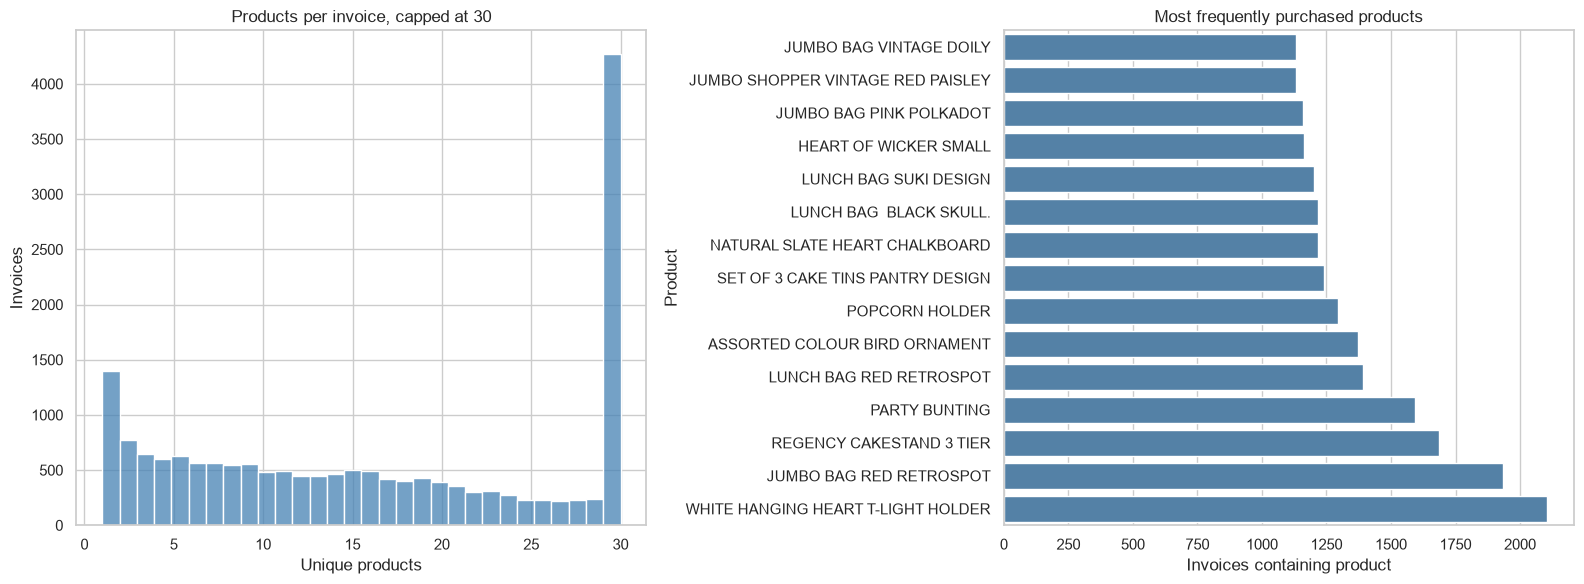

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    invoice_table["unique_products"].clip(upper=30),
    bins=30,
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Products per invoice, capped at 30")
axes[0].set_xlabel("Unique products")
axes[0].set_ylabel("Invoices")

plot_products = top_products.sort_values("invoices")

sns.barplot(
    data=plot_products,
    x="invoices",
    y="description",
    ax=axes[1],
    color="steelblue"
)

axes[1].set_title("Most frequently purchased products")
axes[1].set_xlabel("Invoices containing product")
axes[1].set_ylabel("Product")

plt.tight_layout()
plt.show()

## Exploratory findings

- Original transaction rows: **541,909**
- Clean transaction rows: **473,762**
- Removed rows: **68,147 (12.58%)**
- Cancelled rows: **9,288**
- Unique invoices: **17,902**
- Unique products: **3,909**
- Median products per invoice: **15**
- Mean products per invoice: **26.46**

The most frequently purchased product was **WHITE HANGING HEART T-LIGHT HOLDER**, appearing in **2,104 invoices (11.75%)**. This was followed by **JUMBO BAG RED RETROSPOT** with **1,935 invoices (10.81%)**, **REGENCY CAKESTAND 3 TIER** with **1,685 invoices (9.41%)**, and **PARTY BUNTING** with **1,593 invoices (8.90%)**.

The basket-size distribution was strongly right-skewed. Half of the invoices contained 15 or fewer unique products, while the mean was higher at 26.46 because some invoices were extremely large. The middle 50% of invoices contained between **6 and 29 products**, while the largest invoice contained **1,109 unique products**. These unusually large baskets may represent wholesale customers.

The histogram was capped at 30 products for readability. Therefore, the large final bar represents all invoices containing 30 or more products; it does not mean that every one of those invoices contained exactly 30 products.

Filtering removed cancelled transactions, returns or other non-positive quantities, zero-priced records, non-UK transactions, non-product charges, missing product information and repeated appearances of the same product within an invoice.

In [19]:
ordered_invoices = invoice_table.sort_values(
    ["invoice_date"]
).index

n_invoices = len(ordered_invoices)
discovery_end = int(0.60 * n_invoices)
validation_end = int(0.80 * n_invoices)

discovery_ids = ordered_invoices[:discovery_end]
validation_ids = ordered_invoices[discovery_end:validation_end]
test_ids = ordered_invoices[validation_end:]

split_summary = pd.DataFrame({
    "split": ["Discovery", "Validation", "Test"],
    "invoices": [
        len(discovery_ids),
        len(validation_ids),
        len(test_ids)
    ],
    "start_date": [
        invoice_table.loc[discovery_ids, "invoice_date"].min(),
        invoice_table.loc[validation_ids, "invoice_date"].min(),
        invoice_table.loc[test_ids, "invoice_date"].min()
    ],
    "end_date": [
        invoice_table.loc[discovery_ids, "invoice_date"].max(),
        invoice_table.loc[validation_ids, "invoice_date"].max(),
        invoice_table.loc[test_ids, "invoice_date"].max()
    ]
})

split_summary

,split,invoices,start_date,end_date
0,Discovery,10741,2010-12-01 08:26:00,2011-08-18 10:48:00
1,Validation,3580,2011-08-18 10:49:00,2011-10-26 12:28:00
2,Test,3581,2011-10-26 12:31:00,2011-12-09 12:49:00


In [20]:
basket_series = (
    clean_df.groupby("invoice_no")["stock_code"]
    .agg(frozenset)
)

discovery_baskets = basket_series.loc[
    basket_series.index.intersection(discovery_ids)
].tolist()

validation_baskets = basket_series.loc[
    basket_series.index.intersection(validation_ids)
].tolist()

test_baskets = basket_series.loc[
    basket_series.index.intersection(test_ids)
].tolist()

print("Discovery baskets:", len(discovery_baskets))
print("Validation baskets:", len(validation_baskets))
print("Test baskets:", len(test_baskets))

Discovery baskets: 10741
Validation baskets: 3580
Test baskets: 3581


## 2. FP-Growth and association rules

FP-Growth finds product combinations that occur frequently across baskets.

Instead of generating every possible combination, it compresses transactions into an FP-tree and recursively extracts frequent patterns. This is generally more efficient than Apriori because Apriori repeatedly generates and tests candidate itemsets.

In [21]:
encoder = TransactionEncoder()

encoded_matrix = encoder.fit(
    discovery_baskets
).transform(
    discovery_baskets,
    sparse=True
)

discovery_matrix = pd.DataFrame.sparse.from_spmatrix(
    encoded_matrix,
    columns=encoder.columns_
)

discovery_matrix = discovery_matrix.astype(
    pd.SparseDtype("bool", False)
)

print("Basket matrix shape:", discovery_matrix.shape)
discovery_matrix.head()

Basket matrix shape: (10741, 3597)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4020\2255161437.py:10: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  discovery_matrix = pd.DataFrame.sparse.from_spmatrix(


,10002,10080,10120,10123C,10124A,10124G,10125,10133,10135,11001,...,DCGS0076,DCGSSBOY,DCGSSGIRL,PADS,gift_0001_10,gift_0001_20,gift_0001_30,gift_0001_40,gift_0001_50,m
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
support_values = [0.005, 0.010, 0.020]

support_rows = []
itemset_runs = {}

for minimum_support in support_values:
    start_time = time.perf_counter()

    patterns = fpgrowth(
        discovery_matrix,
        min_support=minimum_support,
        use_colnames=True,
        max_len=3
    )

    runtime = time.perf_counter() - start_time

    patterns["length"] = patterns["itemsets"].apply(len)
    itemset_runs[minimum_support] = patterns

    support_rows.append({
        "minimum_support": minimum_support,
        "minimum_invoices": int(
            np.ceil(
                minimum_support
                * len(discovery_matrix)
            )
        ),
        "frequent_itemsets": len(patterns),
        "runtime_seconds": runtime
    })

support_results = pd.DataFrame(support_rows)
support_results.round(4)

,minimum_support,minimum_invoices,frequent_itemsets,runtime_seconds
0,0.005,54,15131,5.9512
1,0.010,108,2101,2.1909
2,0.020,215,396,1.5582


In [23]:
MIN_SUPPORT = 0.010

frequent_itemsets = itemset_runs[
    MIN_SUPPORT
].copy()

frequent_itemsets = frequent_itemsets.sort_values(
    ["length", "support"],
    ascending=[False, False]
)

frequent_itemsets["length"].value_counts().sort_index()

length
1     761
2    1048
3     292
Name: count, dtype: int64

In [24]:
def describe_itemset(itemset):
    labels = [
        product_lookup.get(code, code)
        for code in sorted(itemset)
    ]

    return " + ".join(labels)


display_itemsets = frequent_itemsets.copy()

display_itemsets["products"] = (
    display_itemsets["itemsets"]
    .apply(describe_itemset)
)

display_itemsets[
    ["products", "length", "support"]
].head(20).round(4)

,products,length,support
1935,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,3,0.0298
832,JUMBO STORAGE BAG SUKI + JUMBO BAG PINK POLKAD...,3,0.0254
971,JUMBO STORAGE BAG SUKI + JUMBO SHOPPER VINTAGE...,3,0.0244
972,JUMBO BAG PINK POLKADOT + JUMBO SHOPPER VINTAG...,3,0.0234
1537,REGENCY CAKESTAND 3 TIER + GREEN REGENCY TEACU...,3,0.0231
1196,LUNCH BAG RED RETROSPOT + LUNCH BAG BLACK SKU...,3,0.0203
1586,JUMBO BAG WOODLAND ANIMALS + JUMBO STORAGE BAG...,3,0.0203
973,JUMBO STORAGE BAG SUKI + JUMBO BAG PINK POLKAD...,3,0.0202
1587,JUMBO BAG WOODLAND ANIMALS + JUMBO BAG PINK PO...,3,0.0201
1283,LUNCH BAG RED RETROSPOT + LUNCH BAG BLACK SKU...,3,0.0196


In [25]:
MIN_CONFIDENCE = 0.25
MIN_LIFT = 1.20

all_rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

candidate_rules = all_rules[
    (all_rules["antecedents"].apply(len) <= 2)
    & (all_rules["consequents"].apply(len) == 1)
    & (all_rules["lift"] >= MIN_LIFT)
    & (all_rules["leverage"] > 0)
].copy()

candidate_rules = candidate_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

print("All generated rules:", len(all_rules))
print("Rules after quality filters:", len(candidate_rules))

All generated rules: 2266
Rules after quality filters: 1920


In [26]:
display_rules = candidate_rules.copy()

display_rules["if_products"] = (
    display_rules["antecedents"]
    .apply(describe_itemset)
)

display_rules["then_product"] = (
    display_rules["consequents"]
    .apply(describe_itemset)
)

display_rules[
    [
        "if_products",
        "then_product",
        "support",
        "confidence",
        "lift",
        "leverage"
    ]
].head(20).round(4)

,if_products,then_product,support,confidence,lift,leverage
0,SET/6 COLLAGE PAPER CUPS,SET/6 COLLAGE PAPER PLATES,0.0103,0.8952,66.3098,0.0102
1,SET/6 COLLAGE PAPER PLATES,SET/6 COLLAGE PAPER CUPS,0.0103,0.7655,66.3098,0.0102
2,REGENCY TEA PLATE ROSES + REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK,0.0112,0.8054,61.7891,0.0110
3,REGENCY TEA PLATE ROSES + REGENCY TEA PLATE PINK,REGENCY TEA PLATE GREEN,0.0112,0.9600,59.6032,0.0110
4,HERB MARKER MINT + HERB MARKER CHIVES,HERB MARKER PARSLEY,0.0136,0.9605,56.0707,0.0134
5,HERB MARKER THYME + HERB MARKER CHIVES,HERB MARKER PARSLEY,0.0135,0.9603,56.0555,0.0133
6,HERB MARKER ROSEMARY + HERB MARKER CHIVES,HERB MARKER PARSLEY,0.0133,0.9597,56.0243,0.0131
7,HERB MARKER BASIL + HERB MARKER CHIVES,HERB MARKER PARSLEY,0.0131,0.9592,55.9923,0.0129
8,HERB MARKER THYME + HERB MARKER CHIVES,HERB MARKER ROSEMARY,0.0134,0.9536,55.9731,0.0132
9,REGENCY TEA PLATE PINK,REGENCY TEA PLATE GREEN,0.0117,0.9000,55.8780,0.0115


In [27]:
item_support = pd.Series(
    np.asarray(
        discovery_matrix.sparse
        .to_coo()
        .mean(axis=0)
    ).ravel(),
    index=discovery_matrix.columns
)

benchmark_columns = item_support[
    item_support >= 0.02
].index

benchmark_matrix = discovery_matrix[
    benchmark_columns
]

benchmark_rows = []
benchmark_outputs = {}

algorithms = {
    "FP-Growth": fpgrowth,
    "Apriori": apriori
}

for algorithm_name, algorithm in algorithms.items():
    start_time = time.perf_counter()

    result = algorithm(
        benchmark_matrix,
        min_support=0.02,
        use_colnames=True,
        max_len=3
    )

    runtime = time.perf_counter() - start_time

    benchmark_outputs[algorithm_name] = result

    benchmark_rows.append({
        "algorithm": algorithm_name,
        "itemsets_found": len(result),
        "runtime_seconds": runtime
    })

benchmark_results = pd.DataFrame(benchmark_rows)
benchmark_results.round(4)

,algorithm,itemsets_found,runtime_seconds
0,FP-Growth,396,0.8023
1,Apriori,396,1.3477


In [28]:
fp_patterns = {
    tuple(sorted(itemset))
    for itemset in benchmark_outputs[
        "FP-Growth"
    ]["itemsets"]
}

apriori_patterns = {
    tuple(sorted(itemset))
    for itemset in benchmark_outputs[
        "Apriori"
    ]["itemsets"]
}

print(
    "Same frequent itemsets:",
    fp_patterns == apriori_patterns
)

Same frequent itemsets: True


## Pattern-mining findings

At a minimum support of **1%**, FP-Growth discovered **2,101 frequent itemsets**:

- 761 single-product itemsets;
- 1,048 two-product itemsets;
- 292 three-product itemsets.

The support sensitivity test demonstrated a substantial trade-off between pattern coverage and computational cost.

| Minimum support | Minimum invoices | Itemsets | Runtime |
|---:|---:|---:|---:|
| 0.5% | 54 | 15,131 | 5.9512 seconds |
| 1.0% | 108 | 2,101 | 2.1909 seconds |
| 2.0% | 215 | 396 | 1.5582 seconds |

Reducing support from 2% to 0.5% produced approximately **38 times more itemsets** and required approximately **3.8 times as much runtime**. The selected 1% threshold provided a reasonable compromise: a product combination needed to appear in at least 108 discovery invoices, but the number of patterns remained manageable.

The frequent itemsets commonly involved coordinated product families, particularly Regency tableware, jumbo bags, lunch bags, herb markers and baking products.

FP-Growth initially generated **2,266 association rules**. After requiring confidence of at least 0.25, lift of at least 1.20, positive leverage, no more than two antecedent products and a single consequent product, **1,920 candidate rules** remained.

Examples of particularly strong discovery-period relationships included:

- **SET/6 COLLAGE PAPER CUPS → SET/6 COLLAGE PAPER PLATES**, with confidence **0.8952** and lift **66.31**;
- **SET/6 COLLAGE PAPER PLATES → SET/6 COLLAGE PAPER CUPS**, with confidence **0.7655** and lift **66.31**;
- combinations of Regency tea plates predicting another matching Regency tea plate;
- combinations of herb markers predicting parsley, rosemary, thyme or chives markers.

The high lift values indicate that these matching products appeared together far more frequently than expected if they were purchased independently. Nevertheless, association does not mean that one product caused the purchase of another.

At the 2% benchmark threshold, FP-Growth and Apriori both discovered exactly **396 itemsets**, confirming that they produced equivalent patterns. FP-Growth completed the task in **0.8023 seconds**, compared with **1.3477 seconds** for Apriori. FP-Growth was approximately **1.68 times faster**, or used about **40.5% less runtime** in this run.

In [29]:
def evaluate_rules_on_baskets(
    rules,
    baskets,
    prefix
):
    total_baskets = len(baskets)
    metric_rows = []

    for row in rules.itertuples():
        antecedent = set(row.antecedents)
        consequent = set(row.consequents)
        combined = antecedent | consequent

        antecedent_count = sum(
            antecedent.issubset(basket)
            for basket in baskets
        )

        consequent_count = sum(
            consequent.issubset(basket)
            for basket in baskets
        )

        joint_count = sum(
            combined.issubset(basket)
            for basket in baskets
        )

        rule_support = joint_count / total_baskets

        rule_confidence = (
            joint_count / antecedent_count
            if antecedent_count > 0
            else np.nan
        )

        consequent_support = (
            consequent_count / total_baskets
        )

        rule_lift = (
            rule_confidence / consequent_support
            if consequent_support > 0
            else np.nan
        )

        rule_leverage = (
            rule_support
            - (
                antecedent_count / total_baskets
            )
            * consequent_support
        )

        metric_rows.append({
            f"{prefix}_antecedent_count":
                antecedent_count,
            f"{prefix}_joint_count":
                joint_count,
            f"{prefix}_support":
                rule_support,
            f"{prefix}_confidence":
                rule_confidence,
            f"{prefix}_lift":
                rule_lift,
            f"{prefix}_leverage":
                rule_leverage
        })

    return pd.concat(
        [
            rules.reset_index(drop=True),
            pd.DataFrame(metric_rows)
        ],
        axis=1
    )

00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:165\u001b\u001b in \u001b\u001b__DW_GET_EXPRESSION_VARIABLE__\u001b\n","\u001bException\u001b\u001b:\u001b not_supported\n"]}


In [30]:
validated_rules = evaluate_rules_on_baskets(
    candidate_rules,
    validation_baskets,
    prefix="validation"
)

validated_rules["confidence_retention"] = (
    validated_rules["validation_confidence"]
    / validated_rules["confidence"]
)

stable_rules = validated_rules[
    (validated_rules["validation_antecedent_count"] >= 10)
    & (validated_rules["validation_lift"] > 1)
    & (validated_rules["confidence_retention"] >= 0.80)
].copy()

fallback_used = False

if len(stable_rules) == 0:
    fallback_used = True

    fallback_pool = validated_rules[
        (validated_rules["validation_antecedent_count"] >= 5)
        & (validated_rules["validation_lift"] > 1)
    ]

    stable_rules = (
        fallback_pool.sort_values(
            [
                "validation_leverage",
                "validation_confidence"
            ],
            ascending=False
        )
        .head(25)
        .copy()
    )

print("Stable validation rules:", len(stable_rules))
print("Fallback used:", fallback_used)

Stable validation rules: 1664
Fallback used: False


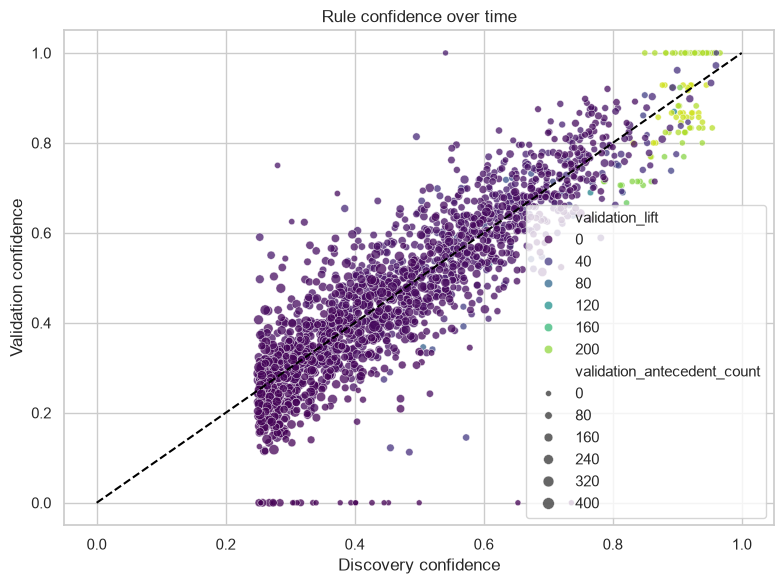

In [31]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=validated_rules,
    x="confidence",
    y="validation_confidence",
    hue="validation_lift",
    size="validation_antecedent_count",
    palette="viridis",
    alpha=0.75
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black"
)

plt.title("Rule confidence over time")
plt.xlabel("Discovery confidence")
plt.ylabel("Validation confidence")
plt.tight_layout()
plt.show()

In [32]:
test_rule_results = evaluate_rules_on_baskets(
    stable_rules,
    test_baskets,
    prefix="test"
)

test_rule_results["test_confidence_retention"] = (
    test_rule_results["test_confidence"]
    / test_rule_results["confidence"]
)

generalization_summary = pd.Series({
    "selected_rules": len(test_rule_results),
    "median_discovery_confidence":
        test_rule_results["confidence"].median(),
    "median_validation_confidence":
        test_rule_results["validation_confidence"].median(),
    "median_test_confidence":
        test_rule_results["test_confidence"].median(),
    "median_test_lift":
        test_rule_results["test_lift"].median(),
    "share_with_test_lift_above_1":
        (test_rule_results["test_lift"] > 1).mean(),
    "median_test_confidence_retention":
        test_rule_results[
            "test_confidence_retention"
        ].median()
})

generalization_summary.round(4)

selected_rules                      1664.0000
median_discovery_confidence            0.4865
median_validation_confidence           0.5064
median_test_confidence                 0.5140
median_test_lift                      11.5573
share_with_test_lift_above_1           0.9904
median_test_confidence_retention       1.0406
dtype: float64

00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:165\u001b\u001b in \u001b\u001b__DW_GET_EXPRESSION_VARIABLE__\u001b\n","\u001bException\u001b\u001b:\u001b not_supported\n"]}


In [33]:
test_display = test_rule_results.copy()

test_display["if_products"] = (
    test_display["antecedents"]
    .apply(describe_itemset)
)

test_display["then_product"] = (
    test_display["consequents"]
    .apply(describe_itemset)
)

test_display[
    [
        "if_products",
        "then_product",
        "confidence",
        "validation_confidence",
        "test_confidence",
        "test_lift",
        "test_leverage",
        "test_antecedent_count"
    ]
].sort_values(
    ["test_leverage", "test_confidence"],
    ascending=False
).head(20).round(4)

,if_products,then_product,confidence,validation_confidence,test_confidence,test_lift,test_leverage,test_antecedent_count
177,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.7500,0.6432,0.7435,7.9954,0.0489,269
178,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.6435,0.5409,0.6006,7.9954,0.0489,333
427,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.5163,0.7000,0.7352,11.8054,0.0412,219
426,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.6072,0.6333,0.7220,11.8054,0.0412,223
191,HOT WATER BOTTLE I AM SO POORLY,CHOCOLATE HOT WATER BOTTLE,0.6053,0.5896,0.5940,7.1143,0.0334,234
192,CHOCOLATE HOT WATER BOTTLE,HOT WATER BOTTLE I AM SO POORLY,0.4570,0.4658,0.4649,7.1143,0.0334,299
1519,JUMBO BAG VINTAGE DOILY,JUMBO BAG RED RETROSPOT,0.4408,0.5199,0.4850,5.6385,0.0296,266
360,VINTAGE HEADS AND TAILS CARD GAME,VINTAGE SNAP CARDS,0.5602,0.6293,0.6568,10.0086,0.0279,169
361,VINTAGE SNAP CARDS,VINTAGE HEADS AND TAILS CARD GAME,0.3548,0.3318,0.4723,10.0086,0.0279,235
1291,LUNCH BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,0.4042,0.4781,0.5220,8.8165,0.0265,205


00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:165\u001b\u001b in \u001b\u001b__DW_GET_EXPRESSION_VARIABLE__\u001b\n","\u001bException\u001b\u001b:\u001b not_supported\n"]}


## Temporal rule validation

- Candidate rules evaluated: **1,920**
- Rules retained after validation: **1,664**
- Percentage of candidate rules retained: **86.67%**
- Fallback selection used: **No**
- Median discovery confidence: **0.4865**
- Median validation confidence: **0.5064**
- Median test confidence: **0.5140**
- Median test lift: **11.5573**
- Rules retaining positive test lift: **99.04%**
- Median test confidence retention: **1.0406**

The validation process retained rules that appeared at least ten times in the validation antecedents, continued to have lift above 1 and retained at least 80% of their original confidence. A total of **256 candidate rules** were removed because they did not satisfy these temporal-reliability requirements.

Overall, the selected rules remained highly stable. Median confidence increased slightly from **48.65% in discovery** to **50.64% in validation** and **51.40% in testing**. Median test confidence retention was **1.0406**, meaning the typical rule achieved approximately 104% of its original discovery confidence.

Approximately **99.04% of the retained rules** continued to have test lift above 1. This shows that almost all selected associations remained positively related during the final future period.

Persistent product relationships included:

- **GARDENERS KNEELING PAD CUP OF TEA ↔ GARDENERS KNEELING PAD KEEP CALM**;
- **ALARM CLOCK BAKELIKE RED ↔ ALARM CLOCK BAKELIKE GREEN**;
- **HOT WATER BOTTLE I AM SO POORLY ↔ CHOCOLATE HOT WATER BOTTLE**;
- **VINTAGE HEADS AND TAILS CARD GAME ↔ VINTAGE SNAP CARDS**;
- **LUNCH BAG RED RETROSPOT ↔ LUNCH BAG BLACK SKULL**;
- **CHARLOTTE BAG PINK POLKADOT ↔ RED RETROSPOT CHARLOTTE BAG**.

The confidence plot still shows that some original candidate rules weakened or disappeared during validation. These unstable rules may have represented temporary promotions, seasonality, changing product availability or sampling noise. This demonstrates why chronological validation was necessary before treating historical associations as reliable recommendations.

In [34]:
rule_bank = []

for row in stable_rules.itertuples():
    consequent = next(iter(row.consequents))

    score = (
        row.validation_confidence
        * np.log1p(row.validation_lift)
    )

    rule_bank.append({
        "antecedent": frozenset(row.antecedents),
        "consequent": consequent,
        "score": score
    })


discovery_product_counts = Counter(
    product
    for basket in discovery_baskets
    for product in basket
)

popular_products = [
    product
    for product, count
    in discovery_product_counts.most_common()
]

known_products = set(encoder.columns_)

In [35]:
def evaluate_basket_completion(
    baskets,
    rule_bank,
    popular_products,
    known_products,
    k=5,
    seed=42
):
    rng = np.random.default_rng(seed)

    eligible_baskets = []

    for basket in baskets:
        known_basket = set(basket) & known_products

        if len(known_basket) >= 2:
            eligible_baskets.append(known_basket)

    rule_covered = 0
    rule_hits = 0
    rule_reciprocal_rank = 0

    popularity_hits = 0
    popularity_reciprocal_rank = 0

    for basket in eligible_baskets:
        hidden_product = rng.choice(
            np.array(
                sorted(basket),
                dtype=object
            )
        )

        visible_basket = basket - {
            hidden_product
        }

        candidate_scores = {}

        for rule in rule_bank:
            antecedent = rule["antecedent"]
            consequent = rule["consequent"]

            if (
                antecedent.issubset(visible_basket)
                and consequent not in visible_basket
            ):
                current_score = candidate_scores.get(
                    consequent,
                    -np.inf
                )

                candidate_scores[consequent] = max(
                    current_score,
                    rule["score"]
                )

        rule_recommendations = [
            product
            for product, score
            in sorted(
                candidate_scores.items(),
                key=lambda pair: pair[1],
                reverse=True
            )[:k]
        ]

        if len(rule_recommendations) > 0:
            rule_covered += 1

        if hidden_product in rule_recommendations:
            rule_hits += 1

            rank = (
                rule_recommendations.index(
                    hidden_product
                )
                + 1
            )

            rule_reciprocal_rank += 1 / rank

        popularity_recommendations = [
            product
            for product in popular_products
            if product not in visible_basket
        ][:k]

        if hidden_product in popularity_recommendations:
            popularity_hits += 1

            rank = (
                popularity_recommendations.index(
                    hidden_product
                )
                + 1
            )

            popularity_reciprocal_rank += 1 / rank

    total = len(eligible_baskets)

    return pd.DataFrame([
        {
            "method": "FP-Growth rules",
            "eligible_baskets": total,
            "coverage": rule_covered / total,
            "hit_rate_at_5": rule_hits / total,
            "hit_rate_when_covered":
                rule_hits / rule_covered
                if rule_covered > 0
                else 0,
            "mean_reciprocal_rank":
                rule_reciprocal_rank / total
        },
        {
            "method": "Popular products",
            "eligible_baskets": total,
            "coverage": 1.0,
            "hit_rate_at_5":
                popularity_hits / total,
            "hit_rate_when_covered":
                popularity_hits / total,
            "mean_reciprocal_rank":
                popularity_reciprocal_rank / total
        }
    ])

In [36]:
completion_results = evaluate_basket_completion(
    baskets=test_baskets,
    rule_bank=rule_bank,
    popular_products=popular_products,
    known_products=known_products,
    k=5,
    seed=SEED
)

completion_results.round(4)

,method,eligible_baskets,coverage,hit_rate_at_5,hit_rate_when_covered,mean_reciprocal_rank
0,FP-Growth rules,3257,0.8112,0.0850,0.1048,0.0569
1,Popular products,3257,1.0000,0.0196,0.0196,0.0117


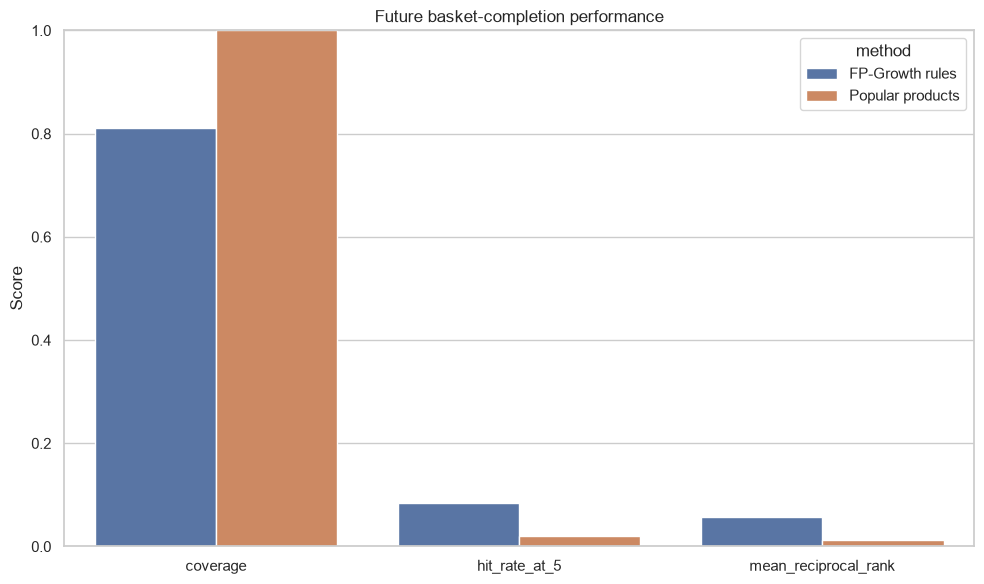

00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:165\u001b\u001b in \u001b\u001b__DW_GET_EXPRESSION_VARIABLE__\u001b\n","\u001bException\u001b\u001b:\u001b not_supported\n"]}
00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:165\u001b\u001b in \u001b\u001b__DW_GET_EXPRESSION_VARIABLE__\u001b\n","\u001bException\u001b\u001b:\u001b not_supported\n"]}
00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  \u001b\u001bFile \u001b\u001b<string>:174\u001b\u001b in \u001b\u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001

In [ ]:
plot_data = completion_results.melt(
    id_vars="method",
    value_vars=[
        "coverage",
        "hit_rate_at_5",
        "mean_reciprocal_rank"
    ],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="metric",
    y="score",
    hue="method"
)

plt.title("Future basket-completion performance")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Basket completion results

The final test period contained 3,581 invoices. Of these, **3,257 baskets (90.95%)** contained at least two products previously observed during the discovery period and were eligible for basket-completion evaluation.

### FP-Growth rules

- Recommendation coverage: **0.8112 (81.12%)**
- Hit rate at 5: **0.0850 (8.50%)**
- Hit rate among covered baskets: **0.1048 (10.48%)**
- Mean reciprocal rank: **0.0569**

The rule-based method generated at least one recommendation for 81.12% of eligible baskets. Across all eligible baskets, the hidden product appeared in the top five recommendations 8.50% of the time. When considering only baskets for which rules produced recommendations, the hit rate increased to 10.48%.

### Popular-product baseline

- Recommendation coverage: **1.0000 (100%)**
- Hit rate at 5: **0.0196 (1.96%)**
- Mean reciprocal rank: **0.0117**

The FP-Growth method clearly outperformed the popular-product baseline. Its hit rate was approximately **4.34 times higher**, while its mean reciprocal rank was approximately **4.86 times higher**.

This demonstrates that using the products already present in a basket provided substantially more relevant recommendations than showing the same globally popular products to every customer.

However, the absolute hit rate remained modest. The rule method did not generate recommendations for **18.88%** of eligible baskets and missed the hidden product in **91.50%** of all evaluated baskets. It should therefore be treated as a useful recommendation signal rather than a complete recommendation system.

Its main advantage was its use of the current basket's product context. Its main limitations were incomplete coverage and difficulty recommending rare products or combinations that did not satisfy the support thresholds.

## Final interpretation

FP-Growth successfully discovered frequent product combinations without using a target variable or predefined customer groups. It was also faster than Apriori while producing the same frequent itemsets in the benchmark.

Most validation-selected rules remained strong in the future test period. Median confidence increased slightly over time, and 99.04% of the selected rules retained lift above 1. This provides evidence that the strongest relationships were not limited to the original discovery period.

The basket-completion experiment supplied the clearest practical evaluation. FP-Growth achieved an 8.50% hit rate at 5, compared with only 1.96% for globally popular products. Therefore, basket-specific product associations contained useful recommendation information.

The retailer could use the strongest validated rules for product-page suggestions, bundle promotions, cross-selling and catalogue organisation. Nevertheless, the method should be combined with other recommendation signals because its coverage and absolute hit rate remain limited.

The discovered rules represent association rather than causation. Purchasing patterns may also reflect seasonality, promotions, wholesale behaviour and product availability.